In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

df = pd.read_csv('Sample - Superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1 — Univariate Analysis

Skewness: 12.973
Mean: 229.86
Median: 54.49


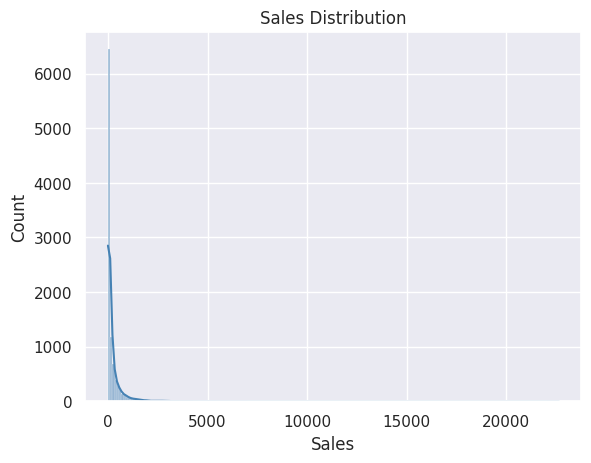

In [2]:
print("Skewness:", round(df['Sales'].skew(), 3))
print("Mean:", round(df['Sales'].mean(), 2))
print("Median:", round(df['Sales'].median(), 2))

sns.histplot(df['Sales'], kde=True, color='steelblue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.show()

Sales is strongly right-skewed because the mean is much higher than the median. The mean is affected by large sales values, so the median is a better summary of a typical order.

## Task 2 — Profit by Category

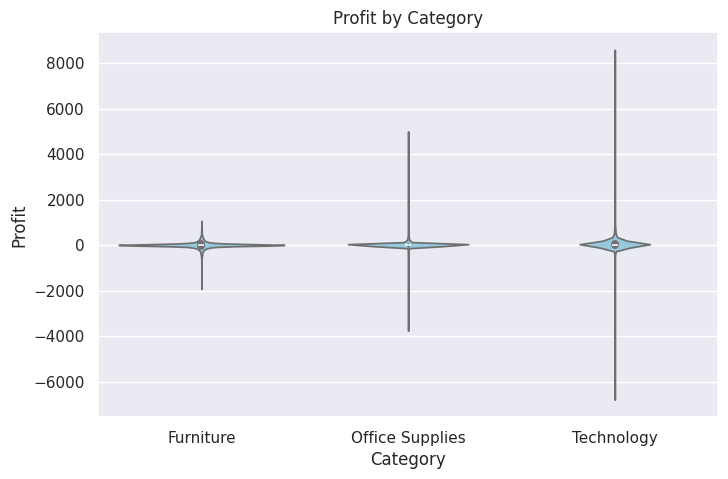

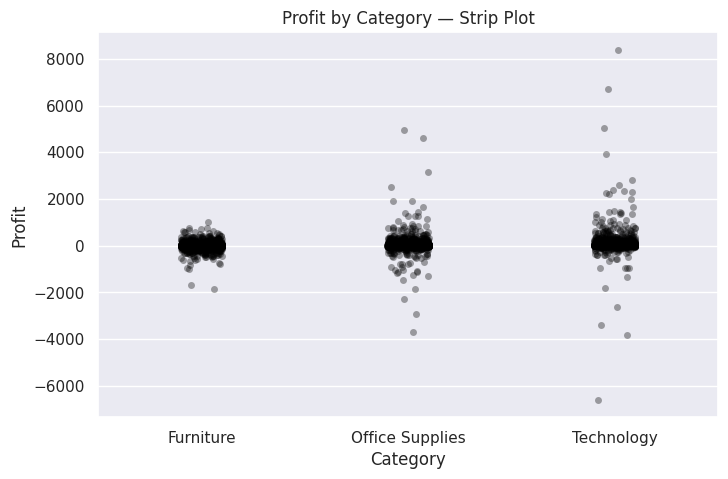

In [3]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Category', y='Profit', color='skyblue')
plt.title('Profit by Category')
plt.show()

plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='Category', y='Profit', jitter=True, alpha=0.35, color='black')
plt.title('Profit by Category — Strip Plot')
plt.show()

The violin plot better reveals a bimodal or widely spread distribution because it shows the shape and density of the data. The strip plot shows the individual observations more clearly.

## Task 3 — Multivariate Encoding

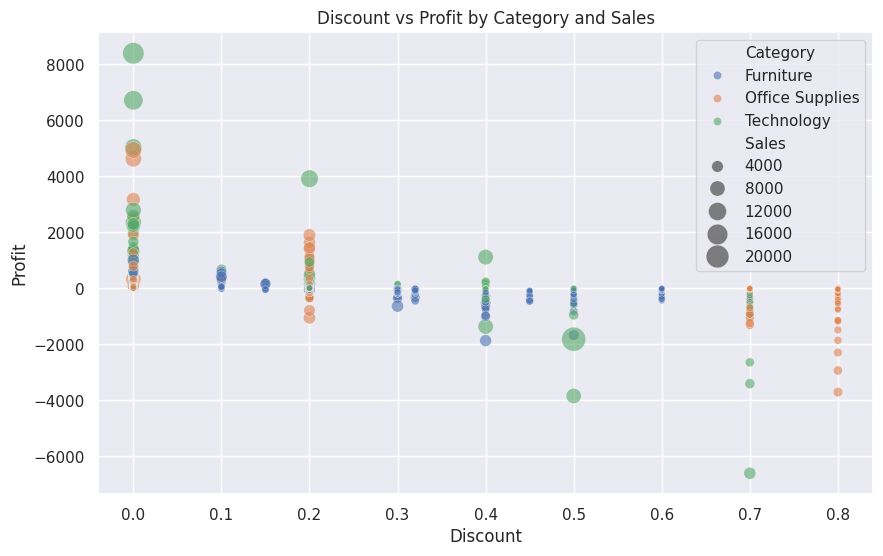

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category', size='Sales', sizes=(20, 300), alpha=0.6)
plt.title('Discount vs Profit by Category and Sales')
plt.show()

The size encoding shows that large-sales orders occur across different profit levels, while the category colors show that these large orders can have very different profit outcomes.

## Task 4 — Pearson vs Spearman Correlation

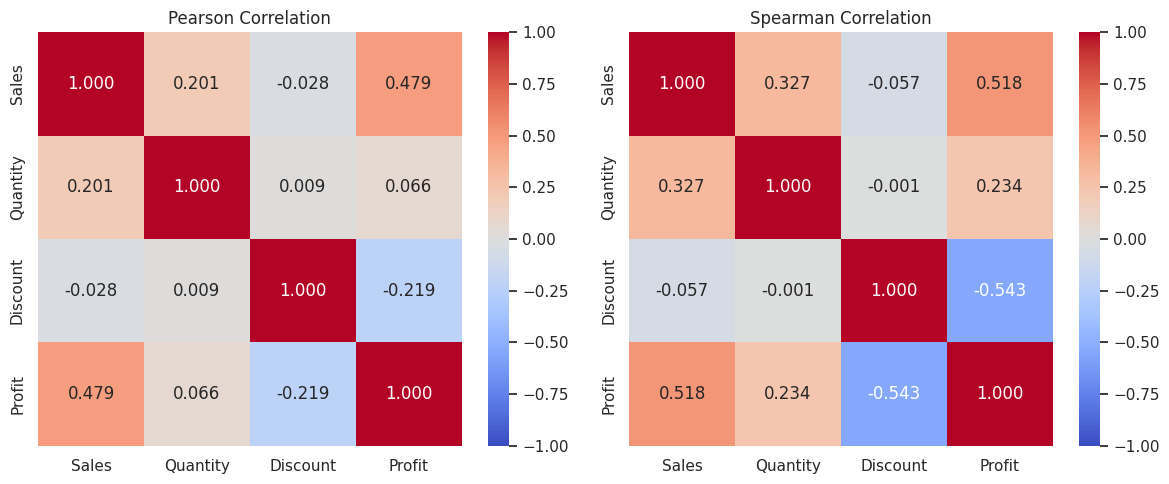

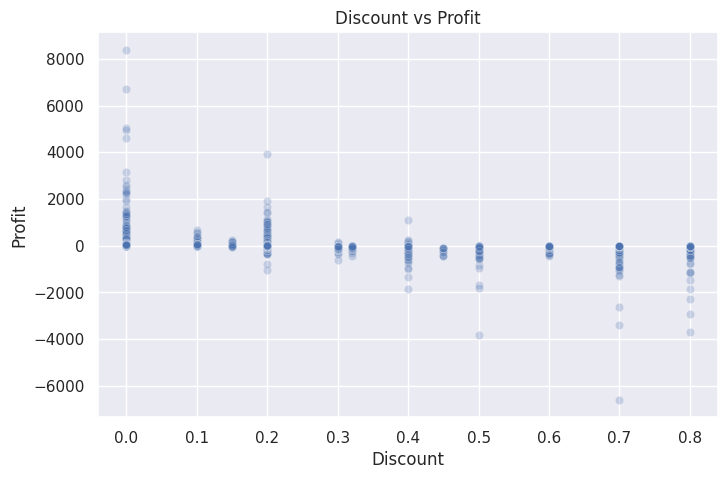

Discount vs Profit - Pearson: -0.219
Discount vs Profit - Spearman: -0.543


In [5]:
numeric = df[['Sales', 'Quantity', 'Discount', 'Profit']]

pearson = numeric.corr(method='pearson')
spearman = numeric.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(pearson, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(spearman, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.25)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

print('Discount vs Profit - Pearson:', round(pearson.loc['Discount', 'Profit'], 3))
print('Discount vs Profit - Spearman:', round(spearman.loc['Discount', 'Profit'], 3))

Discount and Profit show the largest difference: Pearson is about -0.219 while Spearman is about -0.543. The stronger Spearman value suggests a stronger monotonic pattern than the linear Pearson relationship. Correlation does not prove causation.

## Task 5 — Region × Category Sales

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.16,167026.42,170416.31,501239.89
East,208291.20,205516.06,264973.98,678781.24
South,117298.68,125651.31,148771.91,391721.90
West,252612.74,220853.25,251991.83,725457.82
All,741999.80,719047.03,836154.03,2297200.86


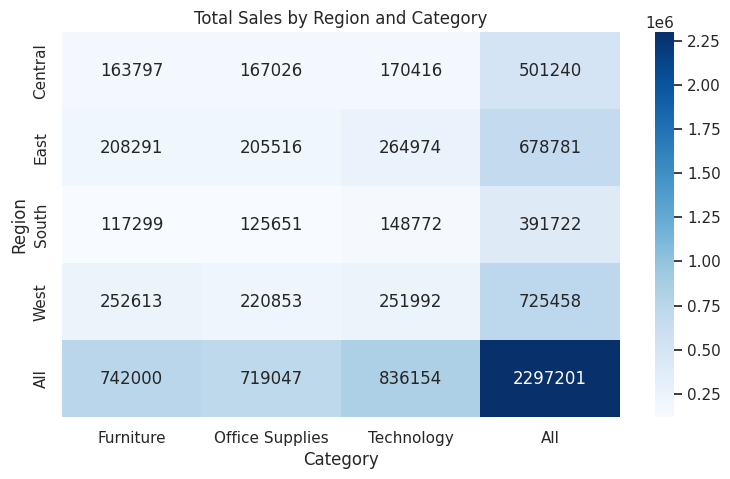

Highest region-category combination: ('East', 'Technology') = 264973.98


In [6]:
pivot = pd.pivot_table(
    df,
    index='Region',
    columns='Category',
    values='Sales',
    aggfunc='sum',
    margins=True
)

display(pivot.round(2))

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Total Sales by Region and Category')
plt.show()

best = df.groupby(['Region', 'Category'])['Sales'].sum().idxmax()
best_value = df.groupby(['Region', 'Category'])['Sales'].sum().max()
print(f"Highest region-category combination: {best} = {best_value:.2f}")

East–Technology contributes the most revenue among the region–category combinations, with total sales of about 264,974.

## Task 6 — Monthly Sales Trend

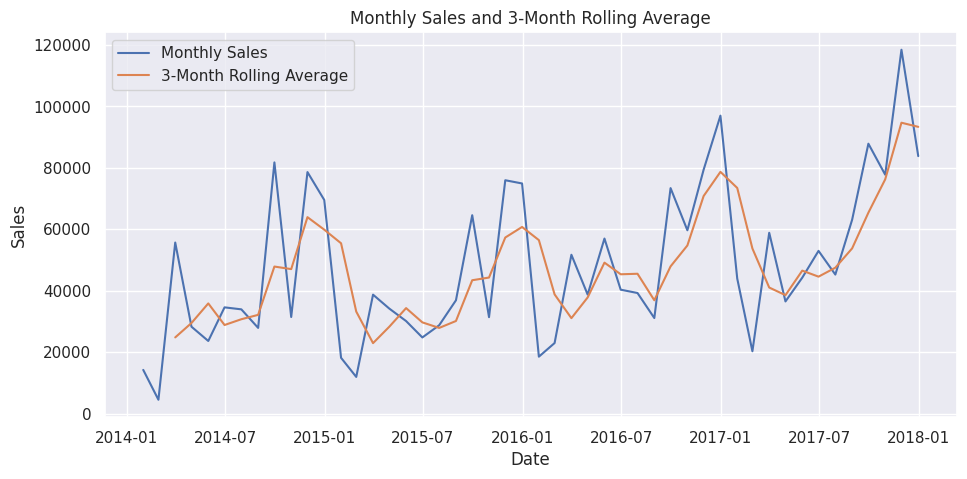

In [7]:
monthly = df.set_index('Order Date')['Sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

plt.figure(figsize=(11, 5))
plt.plot(monthly, label='Monthly Sales')
plt.plot(rolling, label='3-Month Rolling Average')
plt.title('Monthly Sales and 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

The monthly line shows short-term changes and noise. The 3-month rolling average smooths these changes and makes the overall sales trend easier to see.

## Task 7 — Faceting by Region

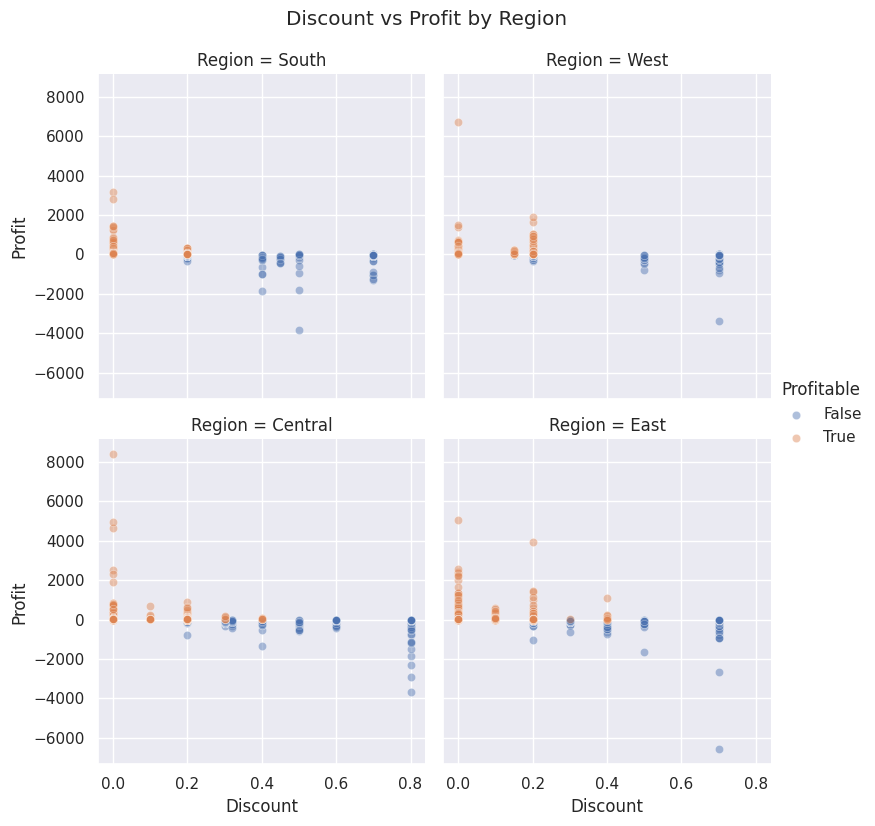

In [8]:
df['Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col='Region', hue='Profitable', col_wrap=2, height=4)
g.map_dataframe(sns.scatterplot, x='Discount', y='Profit', alpha=0.45)
g.add_legend()
g.set_axis_labels('Discount', 'Profit')
g.fig.suptitle('Discount vs Profit by Region', y=1.03)
plt.show()

The West region shows a weaker negative discount–profit relationship than the other regions. Its points are less strongly downward compared with Central, East, and South.

## Task 8 — Overplotting and Annotation

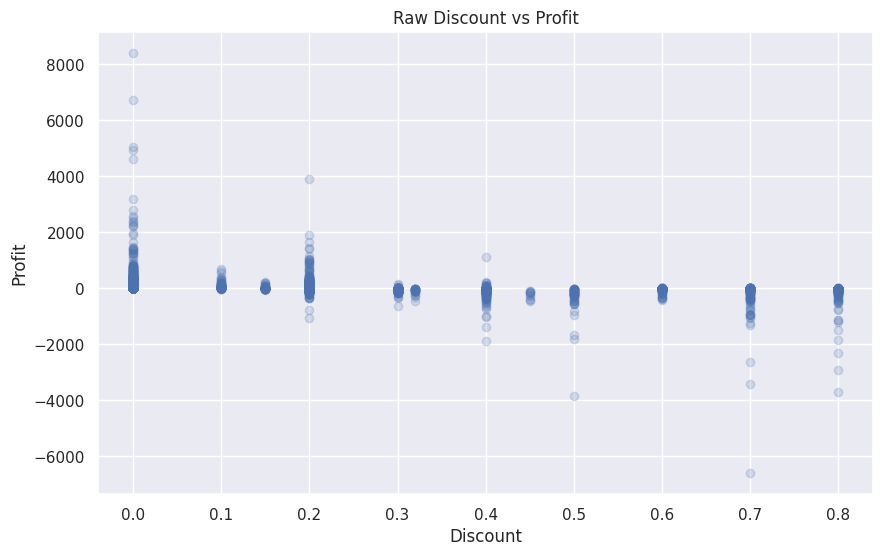

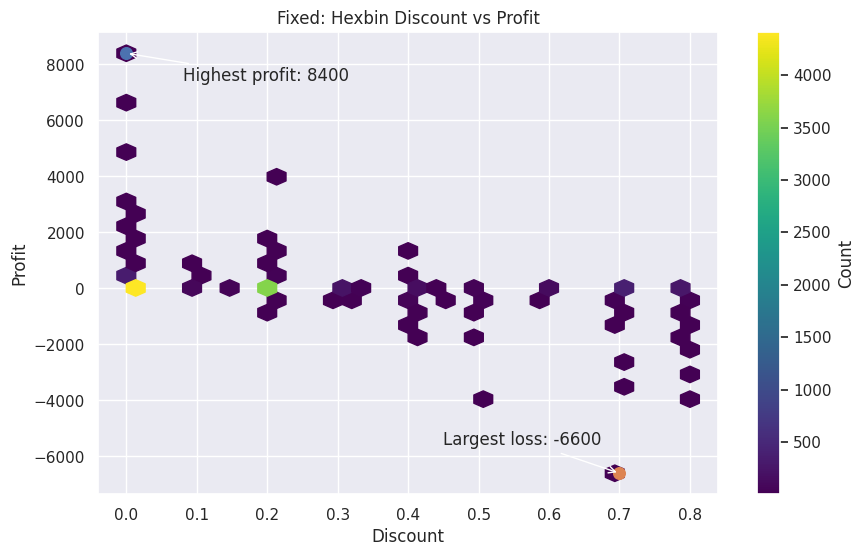

Most profitable order: CA-2016-118689 8399.976
Largest loss: CA-2016-108196 -6599.978


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.2)
plt.title('Raw Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

best = df.loc[df['Profit'].idxmax()]
worst = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(10, 6))
plt.hexbin(df['Discount'], df['Profit'], gridsize=30, mincnt=1, cmap='viridis')
plt.colorbar(label='Count')

plt.scatter(best['Discount'], best['Profit'], s=70)
plt.scatter(worst['Discount'], worst['Profit'], s=70)

plt.annotate(f"Highest profit: {best['Profit']:.0f}",
             (best['Discount'], best['Profit']),
             xytext=(best['Discount'] + 0.08, best['Profit'] - 1000),
             arrowprops=dict(arrowstyle='->'))

plt.annotate(f"Largest loss: {worst['Profit']:.0f}",
             (worst['Discount'], worst['Profit']),
             xytext=(worst['Discount'] - 0.25, worst['Profit'] + 1000),
             arrowprops=dict(arrowstyle='->'))

plt.title('Fixed: Hexbin Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

print('Most profitable order:', best['Order ID'], best['Profit'])
print('Largest loss:', worst['Order ID'], worst['Profit'])

Hexbin is suitable because the dataset has 9,994 orders and many points overlap. It shows the density of orders while keeping the most profitable order and largest loss annotated.